In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
#loaded the dataset
df=pd.read_csv('Position_Salaries.csv')
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [4]:
df.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [5]:
df.isnull().sum()

Position    0
Level       0
Salary      0
dtype: int64

In [6]:
#separating independent & dependent variables
X = df.iloc[:, 1:-1].values
y = df.iloc[:, -1].values
y=y.reshape(-1,1)
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]]
[[  45000]
 [  50000]
 [  60000]
 [  80000]
 [ 110000]
 [ 150000]
 [ 200000]
 [ 300000]
 [ 500000]
 [1000000]]


In [ ]:
sc_y = StandardScaler()
y_scaled = sc_y.fit_transform(y).ravel()
print(y_scaled)

[-0.72004253 -0.70243757 -0.66722767 -0.59680786 -0.49117815 -0.35033854
 -0.17428902  0.17781001  0.88200808  2.64250325]


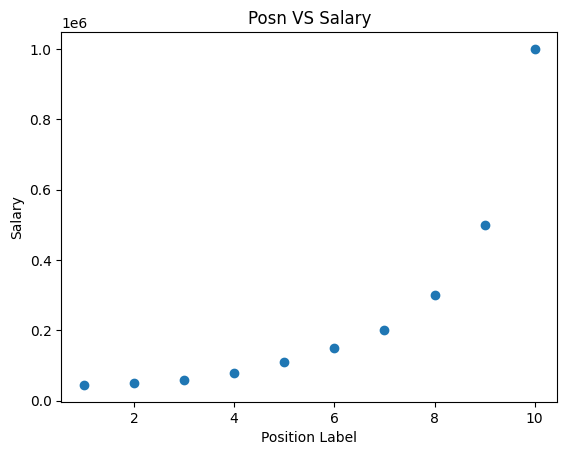

In [ ]:
#check linearity
plt.scatter(X,y)
plt.xlabel('Position Label')
plt.ylabel('Salary')
plt.title('Posn VS Salary')
plt.show()

In [ ]:
#use it if dataset is pretty simple and already in scaled form
#reg=SVR(kernel='rbf') #'rbf' is used for non-linear regression, otherwise use 'linear'
#reg.fit(X,y)

In [ ]:
#y_pred=reg.predict(X)
#print(y_pred)

# PIPELINE
- In this way, X gets automatically scaled, but not y. That's why we scaled y beforehand.
- Another imp pt is that, **StandardScaler** takes **2D** array. Later it's converted again to **1D** array for **SVR** input.


In [ ]:
#we will follow this way for real-world applications

regr = make_pipeline(StandardScaler(), SVR(C=3.0, epsilon=0.02))  #tune C and epsilon to get good R2_Score
regr.fit(X, y_scaled)
#Pipeline(steps=[('standardscaler', StandardScaler()), ('svr', SVR(epsilon=0.2))])

,steps,"[('standardscaler', ...), ('svr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0


In [ ]:
#predicting scaled data
y_pred_scaled = regr.predict(X)
print(y_pred_scaled)

[-0.69988483 -0.72219371 -0.67107879 -0.58270299 -0.47132018 -0.35922679
 -0.1947925   0.20373635  0.90225197  1.59178046]


In [ ]:
#predicting original data
y_pred = sc_y.inverse_transform(y_pred_scaled.reshape(-1,1))
print(y_pred)

[[ 50725.00661971]
 [ 44389.03932204]
 [ 58906.23863515]
 [ 84005.93954771]
 [115639.88343011]
 [147475.63875578]
 [194176.78541788]
 [307363.36596491]
 [505749.48709646]
 [701583.16510664]]


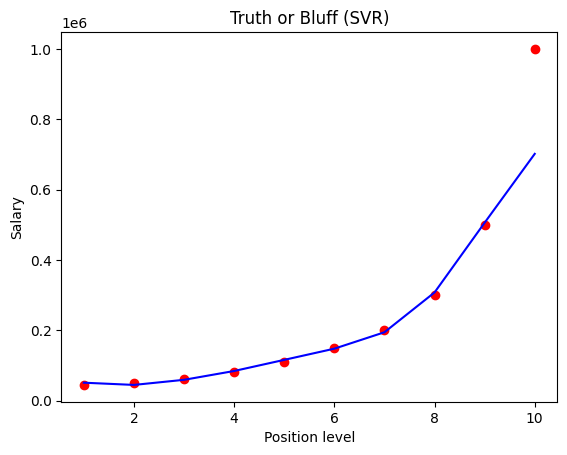

In [ ]:
# Visualising the SVR results
plt.scatter(X, y, color = 'red')
plt.plot(X, sc_y.inverse_transform(y_pred_scaled.reshape(-1,1)), color = 'blue')
plt.title('Truth or Bluff (SVR)')
plt.xlabel('Position level')
plt.ylabel('Salary')
plt.savefig('svr.png')
plt.show()

[[ -5725.00661971]
 [  5610.96067796]
 [  1093.76136485]
 [ -4005.93954771]
 [ -5639.88343011]
 [  2524.36124422]
 [  5823.21458212]
 [ -7363.36596491]
 [ -5749.48709646]
 [298416.83489336]]


<Axes: ylabel='Density'>

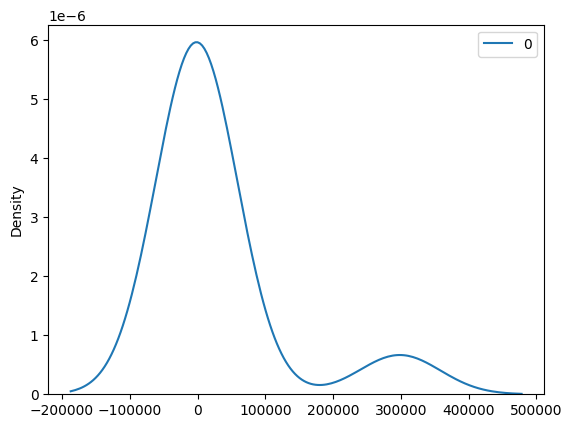

In [ ]:
residual=y-y_pred
print(residual)
sns.kdeplot(residual, color='red')

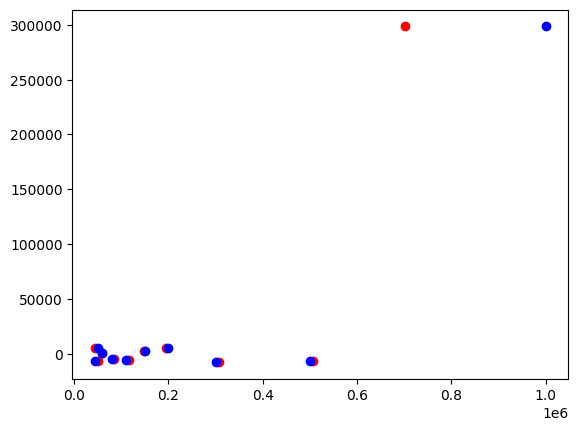

In [ ]:
#checking homoscedasticity
plt.scatter(y_pred, residual, color='red')
plt.scatter(y, residual, color='blue')

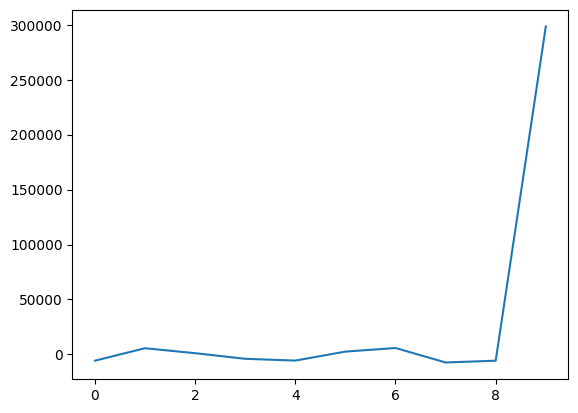

In [ ]:
#checking auto-correlation
plt.plot(residual)

In [ ]:
#evaluation metrics
score=r2_score(y, y_pred)
print(f"r2 score : {score}")
rmse= root_mean_squared_error(y, y_pred)
print(f"RMSE: {rmse}")

r2 score : 0.889299547102953
RMSE: 94495.2253116253
